# Quick Start

This notebook demonstrates fitting a multi-block PLS model with EM estimation (`MBPLS-EM`) on simulated data: two blocks that share some latent structure but also carry block-specific signal. We generate synthetic data with known ground truth, fit the model, and recover which genes carry mostly shared effects, mostly block-specific effects, or a mix of both.

> **Prerequisites:** install the package in editable mode (`pip install -e ".[dev]"`) as described in the README before running this notebook.

This notebook contains:
- Synthetic data generation
- Fitting the model
- Interpreting the results


## Data generation
We use the function "generate_multiblock_mbpls". 

We use the following simulation setting:
- Number of blocks/datasets. K = 2
- Sample size per data block. [100 50]
- Number of variable per data block. d = [100] 
- Shared rank (columns of W). r = 5
- Specific ranks per block (length K). Must satisfy q_k <= d - r. [10 10]
Default values:
- Noise variance(s) for X. Scalar applies to all blocks.
    sig2e : float or list[float]. 0.1 (default)
- Noise variance(s) for Y. Scalar applies to all blocks.
    sig2eps : float or list[float]. 0.1
- RNG seed.
    seed : int or None
- If True, use the same beta across blocks (beta_k = beta for all k).
    shared_beta : bool = False
- If True, use the same phi across blocks (phi_k = phi for all k, with common q if all q_k equal).
    shared_phi : bool =  False
        

In [1]:
# load library

from mbpls_em.simulate import generate_multiblock_mbpls
from mbpls_em.estimators import MBPLS_EM
import numpy as np
import pandas as pd
import random

The following function is to generate random gene's name.

In [2]:
def generate_gene_pool(total_genes=1000):
    """Generates a master pool of unique, realistic mock gene names."""
    random.seed(10123)  # seeded for reproducible gene names across runs
    prefixes = ["BRCA", "TP", "HOX", "EGFR", "IL", "MMP", "STAT", "MYC", "APOE", "VEGFA"]
    suffixes = ["A", "B", "L", "R", "α", "β", "1", "2", ""]
    
    gene_pool = set()
    while len(gene_pool) < total_genes:
        prefix = random.choice(prefixes)
        num = random.randint(1, 200)
        suffix = random.choice(suffixes)
        gene_pool.add(f"{prefix}{num}{suffix}")
        
    return list(gene_pool)


**Note on gene names**: 
in real multi-omics integration, datasets from different platforms or omics layers usually don't measure an identical set of genes. Before fitting a model like this, you'd typically align the datasets first — e.g. an inner join on gene identifier — and keep only the genes common to all blocks. Here, for simplicity, both blocks are simulated with the same number of variables (d=100), so we generate a single shared pool of gene names and apply it to both blocks rather than simulating the alignment step itself.

In [3]:
# Data generation #

data, params, latents = generate_multiblock_mbpls(K=2,
                                                  N_list=[100, 50],
                                                   d= 100,
                                                    r=5,
                                                     q_list=[10, 10],
                                                      seed=10123 )

gene_names = generate_gene_pool(100) # genes names == number of variables d


## Model fitting
We use the "MBPLS-EM" function to fit the model

In [4]:
params_fit, _ = MBPLS_EM(data=data,
                     r=5,
                     q_list=[10, 10])

## Decomposing gene effects: shared vs. block-specific

For each block, MBPLS-EM decomposes a gene's effect on the outcome into two additive parts:
- a **shared** component, driven by structure common to all blocks (`W`, `beta`)
- a **specific** component, driven by structure unique to that block (`P_k`, `phi_k`)

We measure the magnitude of each with the L2 norm across outcome dimensions, then compare which genes are driven mostly by shared structure, mostly by block-specific structure, or a mix of both.


In [5]:
print("Calculating the effects ...")
W = params_fit["W"]
P = params_fit["P"]
beta = params_fit["beta"]
phi = params_fit["phi"]

Calculating the effects ...


In [6]:
# effects  #
shared_effect =[W @ beta_k.T for beta_k in beta]
specific_effect = [P_k @ phi_k.T for phi_k, P_k in zip(phi, P)]
effect_per_data = [shared + specific for shared, specific in zip(shared_effect,specific_effect)]

In [7]:
df_shared_effect =pd.DataFrame(data=np.hstack(shared_effect), index=gene_names)
df_shared_effect["total_shared"] = np.linalg.norm(df_shared_effect, axis=1)
df_shared_effect.head()

,0,1,total_shared
BRCA1142,0.345579,0.081728,0.355112
BRCA114A,-0.574031,-0.274755,0.636397
BRCA150,-0.039111,-0.236858,0.240066
MYC34,0.299903,0.070694,0.308123
HOX163A,0.087792,-0.107948,0.139142


In [8]:
df_specific_effect =pd.DataFrame(data= np.hstack(specific_effect), index=gene_names)
df_specific_effect["total_spec"] = np.linalg.norm(df_specific_effect, axis=1)
df_specific_effect.head()

,0,1,total_spec
BRCA1142,-0.065407,0.490095,0.494440
BRCA114A,-0.457388,0.194479,0.497017
BRCA150,0.180504,-0.117786,0.215535
MYC34,-0.951292,-0.085248,0.955104
HOX163A,0.632743,-0.151168,0.650550


In [9]:
df_effects = pd.concat((df_shared_effect["total_shared"],df_specific_effect["total_spec"]), axis=1)
df_effects["total_effect"] = np.linalg.norm(df_effects, axis=1)
df_effects_sorted = df_effects.sort_values(by="total_effect", ascending=False)
df_effects_sorted.head()

,total_shared,total_spec,total_effect
APOE200α,0.396346,1.543338,1.593419
IL60A,0.297752,1.399660,1.430980
MYC129R,0.457083,1.337873,1.413799
MYC64A,0.871735,1.001180,1.327510
MMP31R,0.111726,1.288013,1.292850


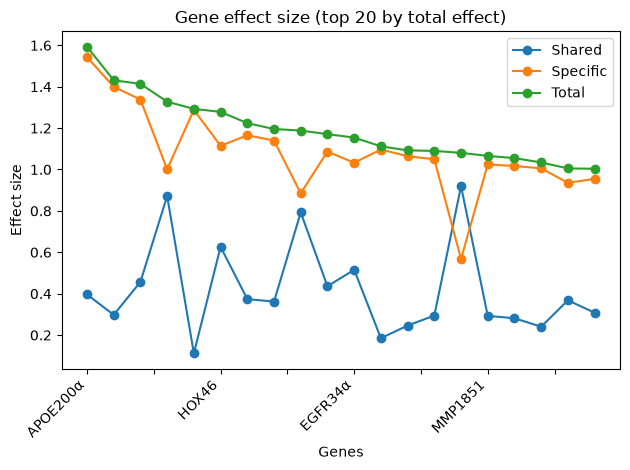

In [10]:
import matplotlib.pyplot as plt

top_genes = df_effects_sorted.head(20)
top_genes.plot(y=top_genes.columns, kind="line", marker="o")
plt.title("Gene effect size (top 20 by total effect)")
plt.xlabel("Genes")
plt.ylabel("Effect size")
plt.xticks(rotation=45, ha="right")
plt.legend(["Shared", "Specific", "Total"])
plt.tight_layout()
# plt.savefig(figures_dir / "gene_effect_size.pdf", format="pdf")
# plt.close()
plt.show()

## Takeaway

Genes near the top of `total_shared` are driven mainly by structure common to both blocks (large `W`, `beta` contribution). Genes near the top of `total_spec` are driven mainly by block-specific structure (large `P_k`, `phi_k` contribution). Genes with a high `total_effect` combine both — compare a gene's `total_shared` against its `total_spec` to see which type of signal dominates for it.
